In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("placement.csv")

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [5]:
df.shape

(100, 4)

In [6]:
df = df.iloc[:, 1:]

In [7]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [8]:
import matplotlib.pyplot as plt

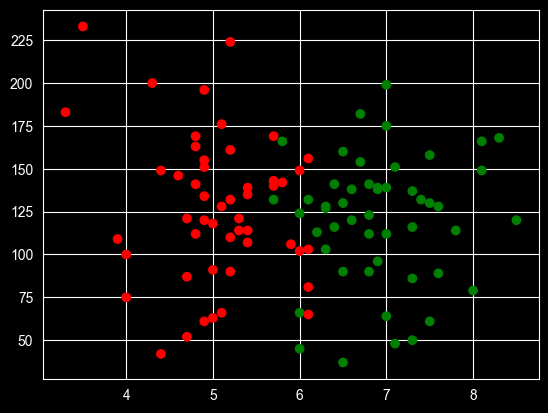

In [9]:
colors = df['placement'].map({0: 'red', 1: 'green'})
plt.scatter(df['cgpa'], df['iq'], c = colors)

In [10]:
X = df.iloc[:, 0:2]
y = df.iloc[:, -1]

In [11]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [12]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1)

In [15]:
X_train

,cgpa,iq
12,5.4,139.0
18,4.0,100.0
36,5.7,140.0
23,4.7,87.0
78,6.1,81.0
...,...,...
1,5.9,106.0
74,6.7,154.0
87,5.7,132.0
13,6.4,116.0


In [16]:
y_train

12    0
18    0
36    0
23    0
78    0
     ..
1     0
74    1
87    1
13    1
20    1
Name: placement, Length: 90, dtype: int64

In [17]:
X_test

,cgpa,iq
93,6.8,112.0
26,7.0,199.0
28,5.2,90.0
48,6.6,138.0
21,7.1,151.0
96,4.4,42.0
89,4.9,151.0
37,8.1,149.0
98,6.3,103.0
55,7.8,114.0


In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

In [20]:
X_train = scaler.fit_transform(X_train)

In [21]:
X_train

array([[-0.48310135,  0.39261987],
       [-1.72790238, -0.59103162],
       [-0.21635827,  0.4178417 ],
       [-1.10550187, -0.91891545],
       [ 0.13929916, -1.07024645],
       [-2.3503029 ,  1.50238052],
       [-0.57201571, -0.06137313],
       [-1.81681674, -0.36403512],
       [ 0.40604224,  0.44306353],
       [-0.12744392,  0.46828537],
       [ 0.85061404,  0.36739803],
       [ 0.13929916, -0.51536612],
       [-2.17247418,  2.76347217],
       [-0.83875879, -0.13703863],
       [-0.66093007, -0.33881329],
       [ 1.02844276, -1.90256693],
       [ 0.0503848 ,  0.6448382 ],
       [ 0.13929916,  0.82139103],
       [ 1.20627148, -0.18748229],
       [-0.74984443,  1.32582769],
       [ 0.9395284 ,  1.30060585],
       [ 1.38410019, -1.57468311],
       [ 1.38410019,  0.16562337],
       [ 1.20627148, -0.94413728],
       [-0.12744392,  1.07360936],
       [-0.57201571, -0.23792596],
       [ 1.47301455,  0.1151797 ],
       [-0.92767315, -1.57468311],
       [-0.66093007,

In [22]:
X_test = scaler.transform(X_test)

In [23]:
X_test

array([[ 0.76169968, -0.28836962],
       [ 0.9395284 ,  1.90592985],
       [-0.66093007, -0.84324995],
       [ 0.58387096,  0.36739803],
       [ 1.02844276,  0.69528186],
       [-1.37224495, -2.05389793],
       [-0.92767315,  0.69528186],
       [ 1.91758635,  0.6448382 ],
       [ 0.31712788, -0.51536612],
       [ 1.65084327, -0.23792596]])

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
clf = LogisticRegression()

In [26]:
#model train
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [29]:
#Evaluate the model

y_pred = clf.predict(X_test)

In [28]:
y_test

93    1
26    1
28    0
48    1
21    1
96    0
89    0
37    1
98    1
55    1
Name: placement, dtype: int64

In [30]:
from sklearn.metrics import accuracy_score

In [31]:
accuracy_score(y_test, y_pred)

1.0

In [32]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

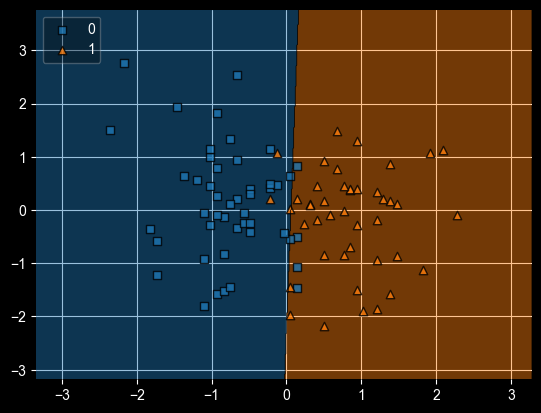

In [33]:
plot_decision_regions(X_train, y_train.values, clf = clf, legend = 2)

In [34]:
import pickle

In [35]:
pickle.dump(clf, open('model.pkl', 'wb'))